In [ ]:
import pandas as pd
import community.community_louvain as community_louvain
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import networkx as nx

In [3]:
df = pd.read_csv("clean-frc-data.csv", low_memory=False)
df

,index,event_code,year,description,tournamentLevel,matchNumber,matchVideoLink,actualStartTime,autoStartTime,postResultTime,...,Red3,Red3_dq,scoreBlueAuto,scoreBlueFinal,scoreBlueFoul,scoreRedAuto,scoreRedFinal,scoreRedFoul,event_date,week
0,0,VA,2006,Qualification 1,Qualification,1,NaN,NaN,NaN,NaN,...,343.0,False,0.0,12.0,0.0,0.0,49.0,0.0,2006-03-01,1
1,1,VA,2006,Qualification 2,Qualification,2,NaN,NaN,NaN,NaN,...,1236.0,False,0.0,7.0,0.0,0.0,24.0,0.0,2006-03-01,1
2,2,VA,2006,Qualification 3,Qualification,3,NaN,NaN,NaN,NaN,...,1598.0,False,0.0,20.0,0.0,0.0,21.0,0.0,2006-03-01,1
3,3,VA,2006,Qualification 4,Qualification,4,NaN,NaN,NaN,NaN,...,612.0,False,0.0,11.0,0.0,0.0,4.0,0.0,2006-03-01,1
4,4,VA,2006,Qualification 5,Qualification,5,NaN,NaN,NaN,NaN,...,346.0,False,0.0,22.0,0.0,0.0,8.0,0.0,2006-03-01,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200556,200556,NEWTON,2024,Match 12 (R4),Playoff,12,https://www.youtube.com/watch?v=kpNo43HyL0A,NaN,NaN,NaN,...,3015.0,False,41.0,139.0,2.0,41.0,93.0,4.0,2024-04-17,8
200557,200557,NEWTON,2024,Match 13 (R5),Playoff,13,https://www.youtube.com/watch?v=xNZrC35HapQ,NaN,NaN,NaN,...,3478.0,False,41.0,90.0,10.0,46.0,110.0,2.0,2024-04-17,8
200558,200558,NEWTON,2024,Final 1,Playoff,14,https://www.youtube.com/watch?v=4mHKHnz2Tok,NaN,NaN,NaN,...,254.0,False,41.0,120.0,0.0,36.0,156.0,19.0,2024-04-17,8
200559,200559,NEWTON,2024,Final 2,Playoff,15,https://www.youtube.com/watch?v=IPILrb2rZOw,NaN,NaN,NaN,...,254.0,False,31.0,130.0,20.0,41.0,175.0,27.0,2024-04-17,8


In [4]:
events = pd.read_csv("frc-events.csv")
events

,allianceCount,weekNumber,announcements,code,divisionCode,name,type,districtCode,venue,city,stateprov,country,dateStart,dateEnd,address,website,webcasts,timezone,year
0,EightAlliance,6,[],ARCHIMEDES,ARCHIMEDES,Championship - Archimedes,ChampionshipSubdivision,NaN,Georgia Dome,Atlanta,GA,USA,2006-04-27T00:00:00,2006-04-29T23:59:59,NaN,NaN,[],Eastern Standard Time,2006
1,EightAlliance,2,[],AZ,NaN,Arizona Regional,Regional,NaN,Arizona Veterans Coliseum,Phoenix,AZ,USA,2006-03-09T00:00:00,2006-03-11T23:59:59,NaN,NaN,[],Mountain Standard Time,2006
2,EightAlliance,4,[],CA,NaN,Southern California Regional,Regional,NaN,Los Angeles Forum,Los Angeles,CA,USA,2006-03-23T00:00:00,2006-03-25T23:59:59,NaN,NaN,[],Pacific Standard Time,2006
3,EightAlliance,6,[],CMP,NaN,Championship,Championship,NaN,Georgia Dome,Atlanta,GA,USA,2006-04-27T00:00:00,2006-04-29T23:59:59,NaN,NaN,[],Eastern Standard Time,2006
4,EightAlliance,5,[],CO,NaN,Colorado Regional,Regional,NaN,Ritchie Center,Denver,CO,USA,2006-03-30T00:00:00,2006-04-01T23:59:59,NaN,NaN,[],Mountain Standard Time,2006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2895,EightAlliance,1,[],WASNO,NaN,PNW District Glacier Peak Event,DistrictEvent,PNW,Glacier Peak High School,Snohomish,WA,USA,2025-02-28T00:00:00,2025-03-02T23:59:59,7401 144th Place SE,http://www.firstwa.org/,[],Pacific Standard Time,2025
2896,EightAlliance,3,[],WAYAK,NaN,PNW District SunDome Event,DistrictEvent,PNW,SunDome State Fair Park,Yakima,WA,USA,2025-03-13T00:00:00,2025-03-15T23:59:59,1301 S. Fair Avenue,http://www.firstwa.org/,[],Pacific Standard Time,2025
2897,EightAlliance,4,[],WILA,NaN,Seven Rivers Regional,Regional,NaN,La Crosse Center,La Crosse,WI,USA,2025-03-19T00:00:00,2025-03-22T23:59:59,300 Harborview Plaza,https://www.firstinspireswi.org/first-robotics...,[],Central Standard Time,2025
2898,EightAlliance,6,[],WIMI,NaN,Wisconsin Regional,Regional,NaN,WI State Fair Park Expo Hall,West Allis,WI,USA,2025-04-03T00:00:00,2025-04-06T23:59:59,640 S 84th St,https://www.firstinspireswi.org/first-robotics...,[],Central Standard Time,2025


In [5]:
matches = pd.merge(
    left=df,#df[df.year == 2023], 
    right=events,
    how='left',
    left_on=['event_code', 'year'],
    right_on=['code', 'year'],
).query("type == @lst", local_dict={'lst': ["DistrictEvent", "Regional"]})
matches = matches[matches.year == 2023]
matches

,index,event_code,year,description,tournamentLevel,matchNumber,matchVideoLink,actualStartTime,autoStartTime,postResultTime,...,venue,city,stateprov,country,dateStart,dateEnd,address,website,webcasts,timezone
163353,163353,ISDE1,2023,Qualification 1,Qualification,1,NaN,NaN,NaN,NaN,...,Metro West High School,Ra'anana,M,Israel,2023-02-26T00:00:00,2023-02-28T23:59:59,Ha-Palmakh St 2,http://firstisrael.org.il,[],Israel Standard Time
163354,163354,ISDE1,2023,Qualification 2,Qualification,2,NaN,NaN,NaN,NaN,...,Metro West High School,Ra'anana,M,Israel,2023-02-26T00:00:00,2023-02-28T23:59:59,Ha-Palmakh St 2,http://firstisrael.org.il,[],Israel Standard Time
163355,163355,ISDE1,2023,Qualification 3,Qualification,3,NaN,NaN,NaN,NaN,...,Metro West High School,Ra'anana,M,Israel,2023-02-26T00:00:00,2023-02-28T23:59:59,Ha-Palmakh St 2,http://firstisrael.org.il,[],Israel Standard Time
163356,163356,ISDE1,2023,Qualification 4,Qualification,4,NaN,NaN,NaN,NaN,...,Metro West High School,Ra'anana,M,Israel,2023-02-26T00:00:00,2023-02-28T23:59:59,Ha-Palmakh St 2,http://firstisrael.org.il,[],Israel Standard Time
163357,163357,ISDE1,2023,Qualification 5,Qualification,5,NaN,NaN,NaN,NaN,...,Metro West High School,Ra'anana,M,Israel,2023-02-26T00:00:00,2023-02-28T23:59:59,Ha-Palmakh St 2,http://firstisrael.org.il,[],Israel Standard Time
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177845,177845,PACA,2023,Match 12 (R4),Playoff,12,https://www.youtube.com/watch?v=EV1h8VzhZXs,NaN,NaN,NaN,...,David L. Lawrence Convention Center,Pittsburgh,PA,USA,2023-04-05T00:00:00,2023-04-08T23:59:59,David L. Lawrence Convention Center 1000 Fort ...,http://www.firstwcpa.org,"['https://www.twitch.tv/firstinspires7', 'http...",Eastern Standard Time
177846,177846,PACA,2023,Match 13 (R5),Playoff,13,https://www.youtube.com/watch?v=xYUJzIUgz9w,NaN,NaN,NaN,...,David L. Lawrence Convention Center,Pittsburgh,PA,USA,2023-04-05T00:00:00,2023-04-08T23:59:59,David L. Lawrence Convention Center 1000 Fort ...,http://www.firstwcpa.org,"['https://www.twitch.tv/firstinspires7', 'http...",Eastern Standard Time
177847,177847,PACA,2023,Final 1,Playoff,14,https://www.youtube.com/watch?v=eUg9xgH3oSw,NaN,NaN,NaN,...,David L. Lawrence Convention Center,Pittsburgh,PA,USA,2023-04-05T00:00:00,2023-04-08T23:59:59,David L. Lawrence Convention Center 1000 Fort ...,http://www.firstwcpa.org,"['https://www.twitch.tv/firstinspires7', 'http...",Eastern Standard Time
177848,177848,PACA,2023,Final 2,Playoff,15,https://www.youtube.com/watch?v=_6l9X50IQoo,NaN,NaN,NaN,...,David L. Lawrence Convention Center,Pittsburgh,PA,USA,2023-04-05T00:00:00,2023-04-08T23:59:59,David L. Lawrence Convention Center 1000 Fort ...,http://www.firstwcpa.org,"['https://www.twitch.tv/firstinspires7', 'http...",Eastern Standard Time


In [12]:
G = nx.Graph()
for index, row in matches.iterrows():
    G.add_edge(int(row["Red1"]), int(row["Red2"]))
    G.add_edge(int(row["Red1"]), int(row["Red3"]))
    G.add_edge(int(row["Red2"]), int(row["Red3"]))
    G.add_edge(int(row["Blue1"]), int(row["Blue2"]))
    G.add_edge(int(row["Blue1"]), int(row["Blue3"]))
    G.add_edge(int(row["Blue2"]), int(row["Blue3"]))

In [14]:
#first compute the best partition
partition = community_louvain.best_partition(G)

C:\Users\mikea\AppData\Local\Temp\ipykernel_10564\1352813613.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', max(partition.values()) + 1)


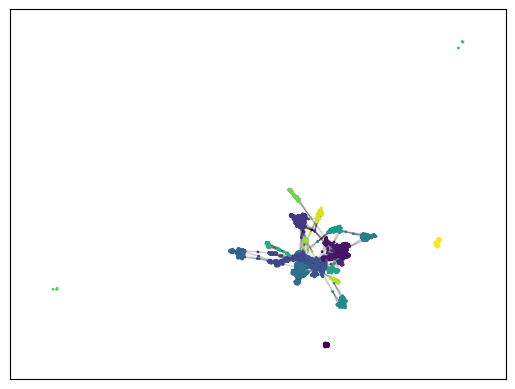

In [22]:
# draw the graph
pos = nx.spring_layout(G)
# color the nodes according to their partition
cmap = cm.get_cmap('viridis', max(partition.values()) + 1)
nx.draw_networkx_nodes(G, pos, partition.keys(), node_size=1,
                       cmap=cmap, node_color=list(partition.values()))
nx.draw_networkx_edges(G, pos, alpha=0.01)
plt.show()

In [23]:
[len(c) for c in sorted(nx.connected_components(G), key=len, reverse=True)]

[2952, 165, 109, 58, 3, 3]